# IN3050/IN4050 Mandatory Assignment 3: Unsupervised Learning

**Name:**

**Username:**

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo" https://www.uio.no/english/about/regulations/studies/studies-examinations/routines-cheating.html By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, April 26, 2024, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a Python program if you prefer.

If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a pdf of your solution which shows the results of the runs.

If you prefer not to use notebooks, you should deliver the code, your run results, and a pdf-report where you answer all the questions and explain your work.

Your report/notebook should contain your name and username.

Deliver one single zipped folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the exercise
This exercise has three parts. The first part is focused on Principal Component Analysis (PCA). You will go through some basic theory, and implent PCA from scratch to do compression and visualization of data.

The second part focuses on clustering using K-means. You will use `scikit-learn` to run K-means clustering, and use PCA to visualize the results.

The last part ties supervised and unsupervised learning together in an effort to evaluate the output of K-means using a logistic regression for multi-class classification approach.

The master students will also have to do one extra part about tuning PCA to balance compression with information lost.


### Tools
You may freely use code from the weekly exercises and the published solutions. In the first part about PCA you may **NOT** use ML libraries like `scikit-learn`. In the K-means part and beyond we encourage the use of `scikit-learn` to iterate quickly on the problems.

# Principal Component Analysis (PCA)
In this section, you will work with the PCA algorithm in order to understand its definition and explore its uses. Some sources for more information on PCA are:
* The syllabus book by Marsland has an overview of the mathematics and coding involved on page 136-137.
* For a more intuitive explanation of PCA, there are many good explanations online, like [this one](https://www.youtube.com/watch?v=FgakZw6K1QQ&t=1s&ab_channel=StatQuestwithJoshStarmer).
* If you are puzzled by what the covariance matrix is, and how it relates to PCA, [this video](https://www.youtube.com/watch?v=Bt4zfx2R9vA&ab_channel=ExploringtheMeaningOfMath) may be useful.

## Implementation: how is PCA implemented?
Here we implement the basic steps of PCA and we assemble them.

### Importing libraries
We start importing the *numpy* library for performing matrix computations, the *pyplot* library for plotting data, and the *syntheticdata* module to import synthetic data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn import datasets
import syntheticdata

### Centering the Data
Implement a function with the following signature to center the data. Remember that every *feature* should be centered.

In [4]:
def center_data(A):
    # INPUT:
    # A    [NxM] numpy data matrix (N samples, M features)
    N,M = A.shape # N samples, M features 
    X = A - A.mean(axis=0) # centered data matrix, computes along the columns (for each feature)
       
    # subtracting the means from the respective columns
    # This results in a centered data matrix X where the mean of each feature (column) is zero.
     
    # OUTPUT:
    # X    [NxM] numpy centered data matrix (N samples, M features)
    return X



Test your function checking the following assertion on *testcase*:

In [5]:
testcase = np.array([[3., 11., 4.3], [4., 5., 4.3], [5., 17., 4.5], [4, 13., 4.4]]) # 4 samples, 3 features
df = pd.DataFrame(testcase)
answer = np.array([[-1., -0.5, -0.075], [0., -6.5, -0.075], [1., 5.5, 0.125], [0., 1.5, 0.025]]) # answer is given
np.testing.assert_array_almost_equal(center_data(testcase), answer) # asserting that the center-function works


### Computing Covariance Matrix

Implement a function with the following signature to compute the covariance matrix. In order to get this at the correct scale, divide by $N - 1$, not $N$. Do not use `np.cov()`.

In [6]:
def compute_covariance_matrix(A):
    # INPUT:
    # A    [NxM] numpy data matrix (N samples, M features)
    
    Y = center_data(A) # centered data matrix
    N = Y.shape[0] # NUMBER OF SAMPLES (rows)
    
    C = (1 / (N-1)) * np.transpose(Y) @ Y # covariance matrix --> how much do Y vary with itself, variance of each feature in the datset. 
    # Diagonal of C-matrix will represent the variance of each feature in the centered data
    # using a normalization factor 1/(N-1) --> 1/(dof - 1) calculating the mean of the population (N samples) - one degree of freedom
    # degrees of freedom refers to the number of independent values in a calculation that are free to vary
    # making the sample variance unbiased
    
    # OUTPUT:
    # C    [MxM] numpy covariance matrix (M features, M features)

    return C

Test your function checking the following assertion on *testcase*:

In [8]:
test_array = np.array([[22., 11., 5.5], [10., 5., 2.5], [34., 17., 8.5], [28., 14., 7]])
answer = np.cov(np.transpose(test_array))
to_test = compute_covariance_matrix(test_array)
np.testing.assert_array_almost_equal(to_test, answer)


### Computing eigenvalues and eigenvectors
Use the linear algebra package of `numpy` and its function `np.linalg.eig()` to compute eigenvalues and eigenvectors. Notice that we take the real part of the eigenvectors and eigenvalues. The covriance matrix *should* be a symmetric matrix, but the actual implementation in `compute_covariance_matrix()` can lead to small round off errors that lead to tiny imaginary additions to the eigenvalues and eigenvectors. These are purely numerical artifacts that we can safely remove.

**Note:** If you decide to NOT use `np.linalg.eig()` you must make sure that the eigenvalues you compute are of unit lenght!

In [10]:
def compute_eigenvalue_eigenvectors(A):
    # INPUT:
    # A    [DxD] numpy matrix
    #
    # OUTPUT:
   
    eigenval,eigenvec = np.linalg.eig(A) # eigval = scalar
    
    # A v = lambda v
    #An eigenvalue λ tells us how the matrix A scales the corresponding eigenvector v 
    #When A acts on v, the result is a vector that is scaled by λ
    
    # Eigenvectors provide directions associated with eigenvalues that remain unchanged 
    # (except for scaling) under the linear transformation represented by matrix A
    
    # Numerical roundoff can lead to (tiny) imaginary parts. We correct that here.
    eigval = eigenval.real
    eigvec = eigenvec.real
    
    return eigval, eigvec

Test your function checking the following assertion on *testcase*:

In [11]:
testcase = np.array([[2, 0, 0], [0, 5, 0], [0, 0, 3]])
answer1 = np.array([2., 5., 3.])
answer2 = np.array([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
x, y = compute_eigenvalue_eigenvectors(testcase)
np.testing.assert_array_almost_equal(x, answer1)
np.testing.assert_array_almost_equal(y, answer2)

### Sorting eigenvalues and eigenvectors
Implement a function with the following signature to sort eigenvalues and eigenvectors.

Remember that eigenvalue `eigval[i]` corresponds to eigenvector `eigvec[:, i]`.

In [12]:
def sort_eigenvalue_eigenvectors(eigval, eigvec):
    # INPUT:
    # eigval    [D] numpy vector of eigenvalues
    # eigvec    [DxD] numpy array of eigenvectors
    
    # Higher eigvals indicate higher eicvecs --> they have higher significance for the underlying system beeing analyzed.
    # The eigvecs that corresponds to higher eigvals capture greater variance or influence in the data of the underlying system
    # These eigvecs represent prinicipal components that explain the most significant
    # directions of variation/behavior encoded by the matrix A
    
    
    i = np.argsort(eigval)[::-1] # take entire array and sort it from max to min
    # OUTPUT:
    sorted_eigval = eigval[i]
    sorted_eigvec = eigvec[:,i]
    # [[1, 2, 3],
     # [4, 5, 6],
      # [7, 8, 9]]) --> sorted_indices = [2, 0, 1]
    # [[3 1 2]
     # [6 4 5]
      # [9 7 8]]
    
    # sorted_eigval    [D] numpy vector of eigenvalues
    # sorted_eigvec    [DxD] numpy array of eigenvectors
   
    return sorted_eigval, sorted_eigvec

Test your function checking the following assertion on *testcase*:

In [13]:
testcase = np.array([[2, 0, 0], [0, 5, 0], [0, 0, 3]])
answer1 = np.array([5., 3., 2.])
answer2 = np.array([[0., 0., 1.], [1., 0., 0.], [0., 1., 0.]])
x, y = compute_eigenvalue_eigenvectors(testcase) # x = eigval, y = eigvec
x, y = sort_eigenvalue_eigenvectors(x, y)
np.testing.assert_array_almost_equal(x, answer1)
np.testing.assert_array_almost_equal(y, answer2)

### PCA Algorithm
Implement a function with the following signature to compute PCA using the functions implemented above.

In [28]:
def pca(A, m):
    # INPUT:
    # A    [NxM] numpy data matrix (N samples, M features)
    # m    integer number denoting the number of learned features (m <= M)
    C = compute_covariance_matrix(A) # covariance matrix of centered data
    
    eigval,eigvec = compute_eigenvalue_eigenvectors(C)
    sorted_eigval,sorted_eigvec = sort_eigenvalue_eigenvectors(eigval,eigvec)
    # OUTPUT:
    # pca_eigvec    [Mxm] numpy matrix containing the eigenvectors (M dimensions, m eigenvectors)
    # P             [Nxm] numpy PCA data matrix (N samples, m features)
    
    pca_eigvec = sorted_eigvec[:,:m] # selsct the first m eiegenvectors
    A = A - A.mean(axis=0) # centering the data --> 
    # REMOVE THE MEAN AND STANDARDIZE THE DATA, ENSURING THAT EACH FEATURE CONTRIBUTES EQUALLY TO THE ANALYSIS
    P = np.dot(A,pca_eigvec) # PCA data matrix / project data onto PCA subspace
    # P REPRESENTS THE DATA PROJECTED ONTO A LOWER-DIMENSIONAL SPACE
    # EACH COLUMN OF P CORRESPONDS TO A NEW FEATURE (DIMENSION) IN THE REDUCED SPACE
    
    
    
    return pca_eigvec, P

Test your function checking the following assertion on *testcase*:

In [29]:
import pickle
testcase = np.array([[22., 11., 5.5], [10., 5., 2.5], [34., 17., 8.5]])
x, y = pca(testcase, 2)

answer1_file = open('PCAanswer1.pkl', 'rb')
answer2_file = open('PCAanswer2.pkl', 'rb')
answer1 = pickle.load(answer1_file)
answer2 = pickle.load(answer2_file)

test_arr_x = np.sum(np.abs(np.abs(x) - np.abs(answer1)), axis=0)
np.testing.assert_array_almost_equal(test_arr_x, np.zeros(2))

test_arr_y = np.sum(np.abs(np.abs(y) - np.abs(answer2)))
np.testing.assert_almost_equal(test_arr_y, 0)

## Understanding: how does PCA work?
We now use the PCA algorithm you implemented on a toy data set in order to understand its inner workings.

### Loading the data
The module *syntheticdata* provides a small synthetic dataset of dimension [100x2] (100 samples, 2 features).

In [31]:
X = syntheticdata.get_synthetic_data1()

### Visualizing the data
Visualize the synthetic data using the function *scatter()* from the *matplotlib* library.

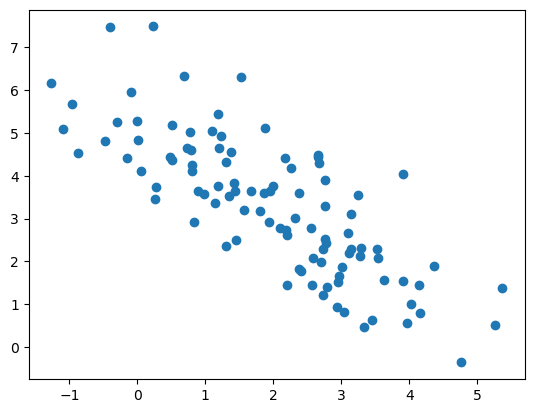

In [32]:
plt.scatter(X[:, 0], X[:, 1])

### Visualize the centered data
Notice that the data visualized above is not centered on the origin (0,0). Use the function defined above to center the data, and the replot it.

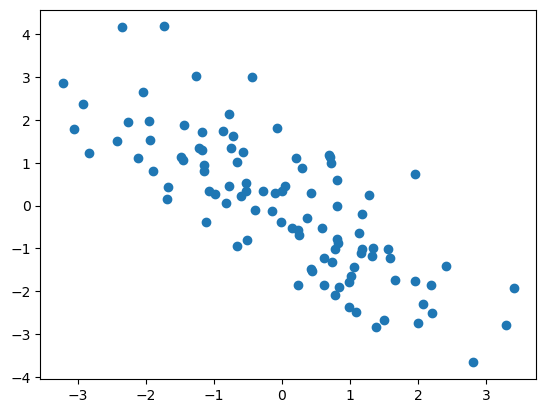

In [33]:
cd1 = center_data(X)
plt.scatter(cd1[:,0], cd1[:,1])

### Visualize the first eigenvector
Visualize the vector defined by the first eigenvector.
To do this you need:
- Use the *PCA()* function to recover the eigenvectors
- Plot the centered data as done above 
- The first eigenvector is a 2D vector (x0,y0). This defines a vector with origin in (0,0) and head in (x0,y0). Use the function *plot()* from matplotlib to plot a line over the first eigenvector.

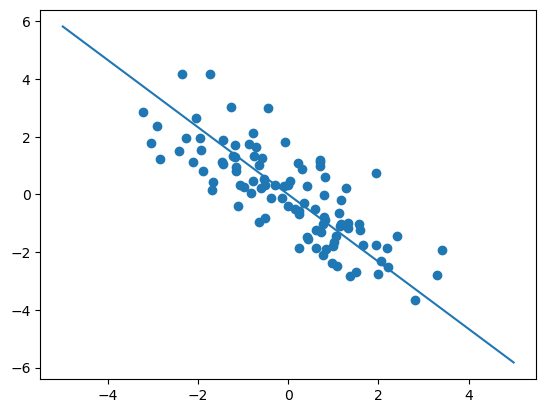

In [34]:
pca_eigvec, _ = pca(X,2) # pca_eigvec shape = (100,2)
first_eigvec = pca_eigvec[0]

plt.scatter(cd1[:,0], cd1[:,1]) # centered data, x og y komponenter, plot av dots

x = np.linspace(-5, 5, 1000) # 1000 evenly spaced values between -5 and 5
y = first_eigvec[1] / first_eigvec[0] * x # first_eigvec[1] / first_eigvec[0] = parameter,
# stigningstallet på linja, y/x, x = -1/100 --> lineær funksjon
plt.plot(x, y)

### Visualize the PCA projection
Finally, use the *PCA()* algorithm to project on a single dimension and visualize the result using again the *scatter()* function.

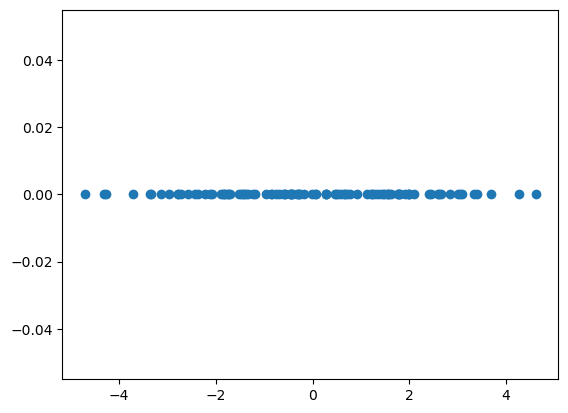

In [41]:
_, P = pca(X,2)
#print(P.shape) # (100,2)
#print(cd1.shape) # (100,2)
#project = cd1 * P # project the centered data onto lower dimensinal space

project = P[:, 0] # SELECT THE FIRST PRINCIPAL COMPKNENT

plt.scatter(project, np.zeros_like(project)) # visualizing the 1d projection of the dataset along a single dimension, y = zero

## Evaluation: when are the results of PCA sensible?
So far we have used PCA on synthetic data. Let us now imagine we are using PCA as a pre-processing step before a classification task. This is a common setup with high-dimensional data. We explore when the use of PCA is sensible.

### Loading the first set of labels
The function *get_synthetic_data_with_labels1()* from the module *syntethicdata* provides a first labeled dataset.

In [42]:
X, y = syntheticdata.get_synthetic_data_with_labels1() 
# X = (100,2), y = (100,1) 0 or 1, the colors of the dots with coordinates X(x0,y0)

### Running PCA
Process the data using the PCA algorithm and project it in one dimension. Plot the labeled data using *scatter()* before and after running PCA. Comment on the results.

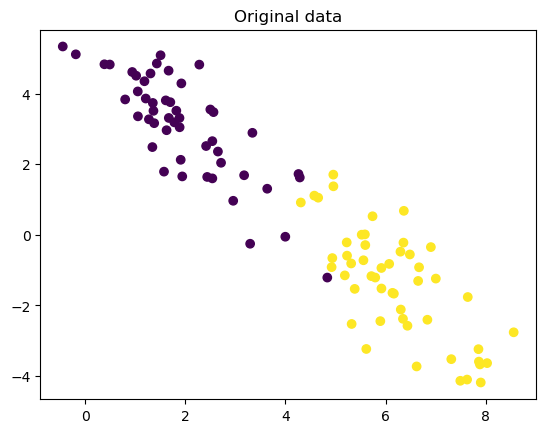

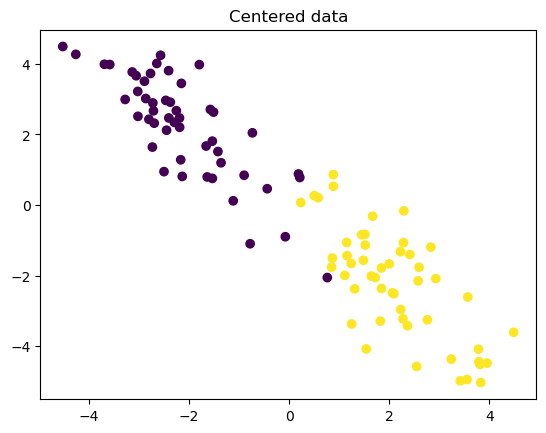

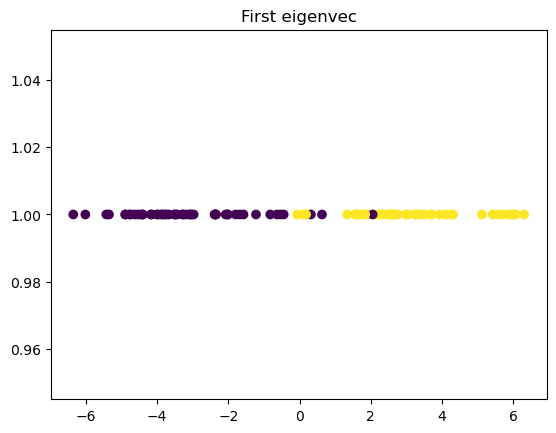

In [43]:
plt.figure()
plt.title(f'Original data')
plt.scatter(X[:,0], X[:,1], c=y[:, 0]) # original data

_, P2 = pca(X,1) # 1 represents dimensions
cd2 = center_data(X)

plt.figure()
plt.title(f'Centered data')
plt.scatter(cd2[:,0], cd2[:,1], c=y[:, 0]) # centered data

plt.figure()
plt.title(f'First eigenvec')
plt.scatter(P2[:,0], np.ones(P2.shape[0]), c=y[:, 0]) # first dimension of P2


**Comment:** Enter your comment here.

The projection of data from 2d down to 1d is like watching the dataset from the side, like watching the side of a flat disc.
What we observe is the distribution of data, and in this case it is nicely separated. What we don't see is the shape of the flat disc, in other words there is no way to tell how far from us the different dots are or how far away they are from each other in the second dimension. When we only observe it in 1d there is no way to tell if there is a second dimension there at all - if this plot is the only data presented to us.
It captures the variance, in this case high variance, since the data seems to be clustered 

### Loading the second set of labels
The function *get_synthetic_data_with_labels2()* from the module *syntethicdata* provides a second labeled dataset.

In [44]:
X, y = syntheticdata.get_synthetic_data_with_labels2()

### Running PCA
As before, process the data using the PCA algorithm and project it in one dimension. Plot the labeled data using *scatter()* before and after running PCA. Comment on the results.

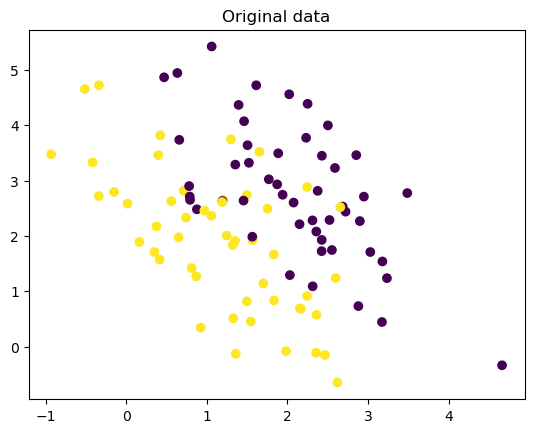

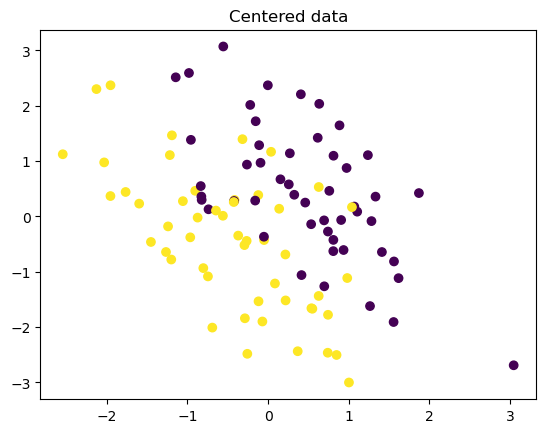

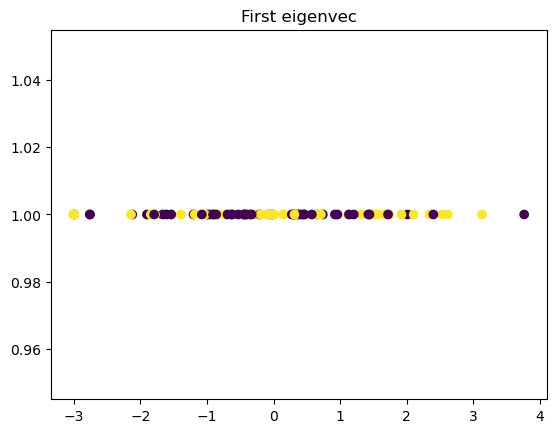

In [46]:
plt.figure()
plt.title(f'Original data')
plt.scatter(X[:,0], X[:,1], c=y[:, 0]) # original data

_, P3 = pca(X,1) # 1 represents dimensions
cd3 = center_data(X)

plt.figure()
plt.title(f'Centered data')
plt.scatter(cd3[:,0], cd3[:,1], c=y[:, 0]) # centered data

plt.figure()
plt.title(f'First eigenvec')
plt.scatter(P3[:,0], np.ones(P3.shape[0]), c=y[:, 0]) # first dimension of P3


**Comment:** Enter your comment here.

Since the dots are more mixed into each other, the projection becomes messy. if the 1d projection were the data presented to us, it would be reasonable to assume that some of the dots would be mixed into each other, and some of them could also have the same values along 1 axis, but stil be placed apart in the other dimension. We have lower variance and a more uniform distribution  

How would the result change if you were to consider only the second eigenvector?
What about if you were to consider both eigenvectors?

**Answer**:
We would capture the remaning variance not captured by first eigenvec. 1. and 2. eiegenvec complement each other, and are orthogonal. with both eigenvecs in one plot we could observe how they both represent different aspects of the variability from the original dataset

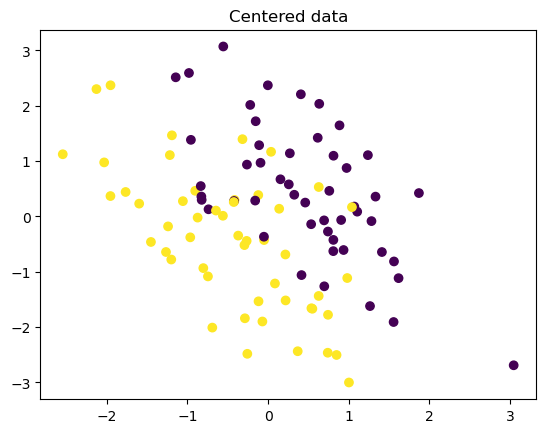

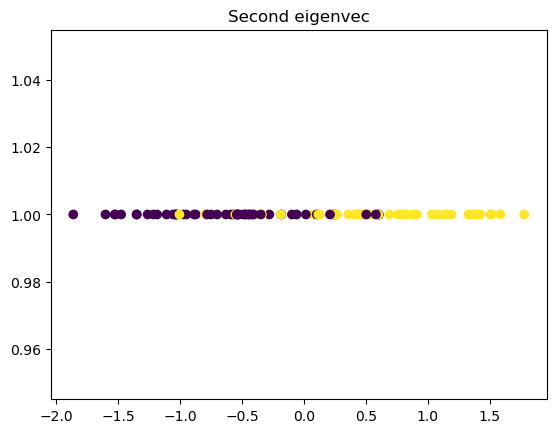

In [47]:
cd3 = center_data(X)

plt.figure()
plt.title(f'Centered data')
plt.scatter(cd3[:,0], cd3[:,1], c=y[:, 0])

_, P3 = pca(X,2) # 2 represents dimensions
#project2 = cd2*P2
#plt.scatter(project2, np.zeros_like(project2))

plt.figure()
plt.title(f'Second eigenvec')
plt.scatter(P3[:,1], np.ones(P3.shape[0]),c=y[:, 0]) # second eigenvec


## Case study 1: PCA for visualization
We now consider the *iris* dataset, a simple collection of data (N=150) describing iris flowers with four (M=4) features. The features are: Sepal Length, Sepal Width, Petal Length and Petal Width. Each sample has a label, identifying each flower as one of 3 possible types of iris: Setosa, Versicolour, and Virginica.

Visualizing a 4-dimensional dataset is impossible; therefore we will use PCA to project our data in 2 dimensions and visualize it.

### Loading the data
The function *get_iris_data()* from the module *syntethicdata* returns the *iris* dataset. It returns a data matrix of dimension [150x4] and a label vector of dimension [150].

In [48]:
import seaborn as sns
X, y = syntheticdata.get_iris_data()
print(X.shape)

(150, 4)


### Visualizing the data by selecting features
Try to visualize the data (using label information) by randomly selecting two out of the four features of the data. You may try different pairs of features.


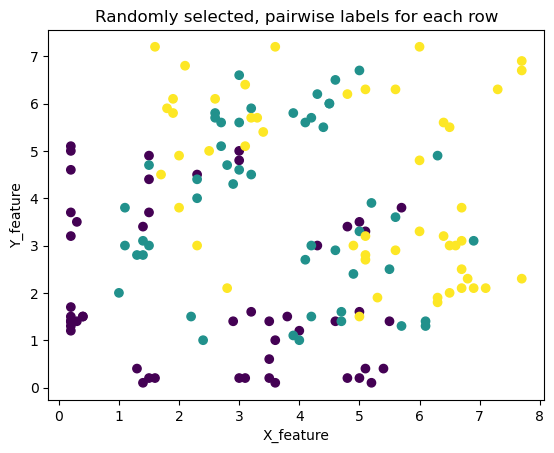

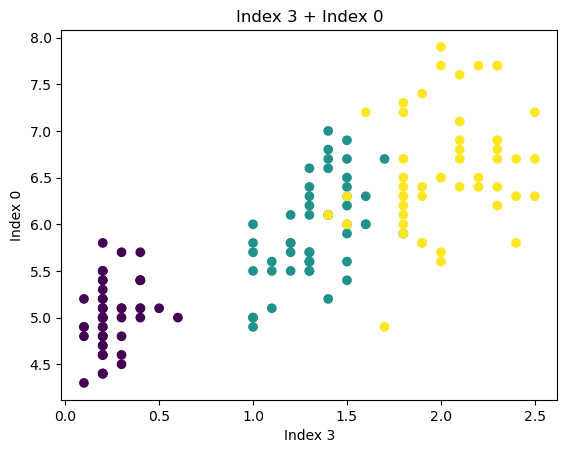

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [53]:
N,M = X.shape # N = rows (samples), M = samples (features)

rand_features = np.zeros((N,2)) # array to store pairwise, randomly picked features
# rand_pick = from 0 to M-1 (0,1,2,3)
rand_pick = np.random.choice(M,size=2,replace=False) # replace = False --> same element cannot be chosen more than once


for i in range(N):
    # rand_pick = from 0 to M-1 (0,1,2,3)
    rand_pick = np.random.choice(M,size=2,replace=False) # replace = False --> same element cannot be chosen more than once
    # pairwise randomly picked features
    rand_features[i] = X[i,rand_pick] # picks out 2 values from X based on the 2 randomly generated indexes

plt.figure()
plt.scatter(rand_features[:,0],rand_features[:,1], c=y)
plot_title = f"Randomly selected, pairwise labels for each row"
plt.title(plot_title)
plt.xlabel(f"X_feature")
plt.ylabel(f"Y_feature")
plt.show()

plt.figure()


for i in range(N):
    # rand_pick = from 0 to M-1 (0,1,2,3)
    #rand_pick = np.random.choice(M,size=2,replace=False) # replace = Flase --> same element cannot be chosen more than once
    # pairwise randomly picked features
    rand_features[i] = X[i,rand_pick] # picks out the 2 values from X based on the 2 randomly generated indexes

X_label = rand_pick[0] # to print on the  axis
Y_label = rand_pick[1] # to print on the  axis

plt.scatter(rand_features[:,0],rand_features[:,1], c=y)
plot_title = f"Index {X_label} + Index {Y_label}"
plt.title(plot_title)
plt.xlabel(f"Index {X_label}")
plt.ylabel(f"Index {Y_label}")
plt.show()

plt.figure()




### Visualizing the data by PCA
Process the data using PCA and visualize it (using label information). Compare with the previous visualization and comment on the results.

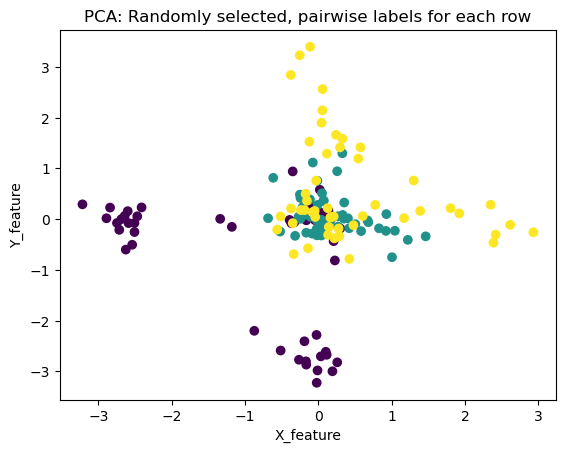

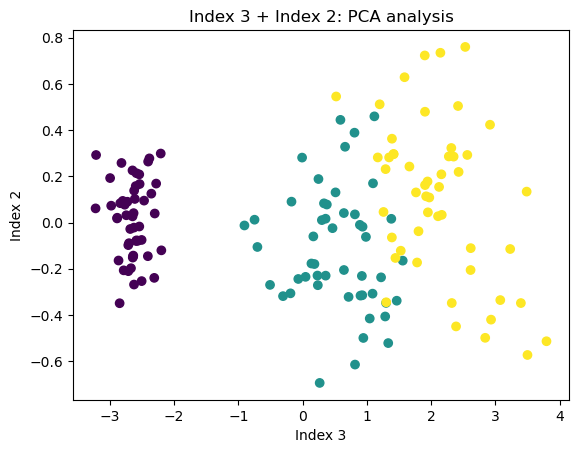

In [57]:
N,M = X.shape # N = rows, M = features
rand_features = np.zeros((N,2)) # array to store pairwise, randomly picked features
rand_pick = np.random.choice(M,size=2,replace=False)


#cd4 = center_data(X) # center data
eigenvector, P4 = pca(X,4) # 1 represents 1d, 2 = 2d

#plt.figure()
#plt.scatter(P4[:,0], P4[:,2], c=y)

for i in range(N):
    # rand_pick = from 0 to M-1 (0,1,2,3)
    rand_pick = np.random.choice(M,size=2,replace=False) # replace = False --> same element cannot be chosen more than once
    # pairwise randomly picked features
    rand_features[i] = P4[i,rand_pick] # picks out the values from p4 based on the 2 randomly generated indexes

X_label = rand_pick[0]
Y_label = rand_pick[1]
    
plt.figure()
plt.scatter(rand_features[:,0],rand_features[:,1], c=y)
plot_title = f"PCA: Randomly selected, pairwise labels for each row"
plt.title(plot_title)
plt.xlabel(f"X_feature")
plt.ylabel(f"Y_feature")
plt.show()


#cd5 = center_data(X)
eigenvector, P5 = pca(X,4) # 1 represents 1d, 2 = 2d

plt.figure()
plt.scatter(P5[:,0], P5[:,2], c=y) 


plot_title = f"Index {X_label} + Index {Y_label}: PCA analysis"
plt.title(plot_title)
plt.xlabel(f"Index {X_label}")
plt.ylabel(f"Index {Y_label}")
plt.show()


**Comment:** When comparing the "Randomly selected, pairwise labels"-plots, we see a much greater structure in the data when PCA analysis is performed. In the first plot, the dots are just smeared out everywhere, and it is not easy to make any sense of it. When performing PCA-analysis in 2d, we get to see the variance in 2d, projected down from higher dimensions, and we observe a cluster of one class, while the 2 others overlap.

Also, when considering the same randomly generated indexes overall, we get a more structured plot with PCA-analysis

## Case study 2: PCA for compression
We now consider the *faces in the wild (lfw)* dataset, a collection of pictures (N=1280) of people. Each pixel in the image is a feature (M=2914).

### Loading the data
The function `get_lfw_data()` from the module `syntethicdata` returns the `lfw` dataset. It returns a data matrix of dimension [1280x2914] and a label vector of dimension [1280]. It also returns two parameters, $h$ and $w$, reporting the height and the width of the images (these parameters are necessary to plot the data samples as images). Beware, it might take some time to download the data. Be patient :) 

In [61]:
X, y, h, w = syntheticdata.get_lfw_data()


### Inspecting the data
Choose one datapoint to visualize (first coordinate of the matrix $X$) and use the function [imshow()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) to plot and inspect some of the pictures.

Notice that *imshow* receives as a first argument an image to be plot; the image must be provided as a rectangular matrix, therefore we reshape a sample from the matrix $X$ to have height $h$ and width $w$. The parameter *cmap* specifies the color coding; in our case we will visualize the image in black-and-white with different gradations of grey.

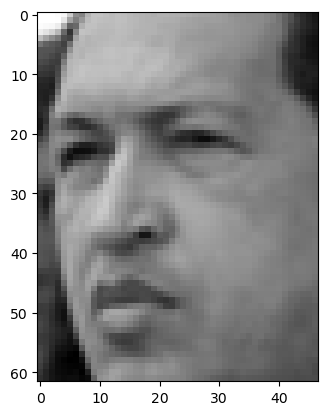

In [62]:
plt.imshow(X[0, :].reshape((h, w)), cmap=plt.cm.gray)

### Implementing a compression-decompression function
Implement a function that first uses PCA to project samples in low-dimensions, and the reconstruct the original image.

*Hint:* Most of the code is the same as the previous PCA() function you implemented.

In [77]:
def encode_decode_pca(A, m):
    # INPUT:
    # A    [NxM] numpy data matrix (N samples, M features)
    # m    integer number denoting the number of learned features (m <= M)
    # OUTPUT:
    # Ahat [NxM] numpy PCA reconstructed data matrix (N samples, M features)
    
    C = compute_covariance_matrix(A) # covariance matrix of centered data
    
    eigval,eigvec = compute_eigenvalue_eigenvectors(C)
    sorted_eigval,sorted_eigvec = sort_eigenvalue_eigenvectors(eigval,eigvec)
    
    pca_eigvec = sorted_eigvec[:,:m] # select the top m eigenvectors
    
    A_centered = A - A.mean(axis=0) # centering the data
    P = np.dot(A_centered,pca_eigvec) # Projects the centered data onto the PCA subspace defined by the top principal components.
    
    # reconstructing the data
    # P @ pca_eigvec.T: Transforms the projected data back into the original feature space using the principal components.
    # A.mean: Adds the mean of the original data to shift the reconstructed data back to its original scale and position.
    Ahat = P @ pca_eigvec.T + A.mean(axis=0) # from chat GPT
    
    return Ahat


### Compressing and decompressing the data
Use the implemented function to encode and decode the data by projecting on a lower dimensional space of dimension 200 (m=200).

In [64]:
Xhat = encode_decode_pca(X, 200) # 200 principal components

### Inspecting the reconstructed data
Use the function *imshow* to plot and compare original and reconstructed pictures. Comment on the results.

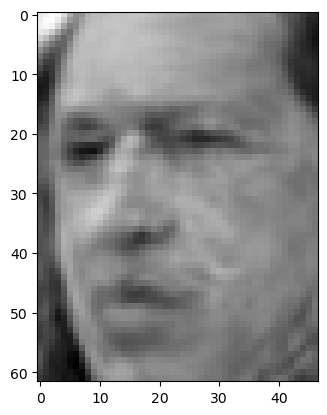

In [65]:
plt.imshow(Xhat[0, :].reshape((h, w)), cmap=plt.cm.gray)

**Comment:** When we reconstruct the data, after performing PCA, we don't get the original picture back. That is because the less important information is discarded when performing PCA. Then, when we reconstruct, this information is lost, but if we increase the principal components, we still keep the most important information in the picture. 1000 will yield a better result. 

### Evaluating different compressions
Use the previous setup to generate compressed images using different values of low dimensions in the PCA algorithm (e.g.: 100, 200, 500, 1000). Plot and comment on the results. Try to use `plt.subplot(n_rows, n_cols, position)`, in addition to titles, to get a nice plot.

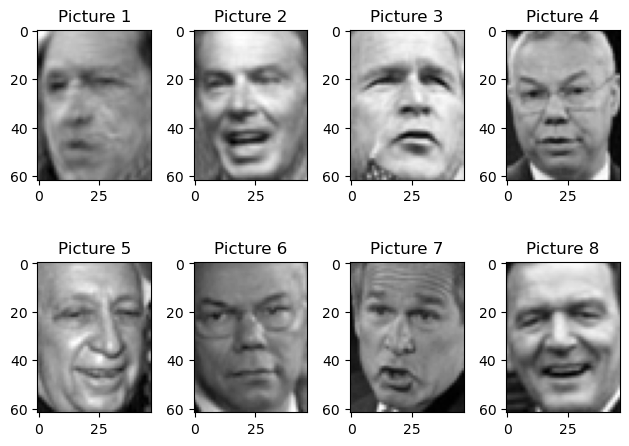

In [66]:
n_rows,n_cols = 2,4
low_dim = 150

for j in range(0,n_rows*n_cols):
    
    Xhat = encode_decode_pca(X, low_dim) # calling encode/decode PCA
    
    plt.subplot(n_rows,n_cols,j+1) # making cols*rows subplots
    
    plt.imshow(Xhat[j, :].reshape((h, w)), cmap=plt.cm.gray) # plotting the decomposed pic
    
    plt.title(f'Picture {j+1}') # adding title to the pictures
    
    low_dim += 150 # low dims increase with 150 low dimensions for each plot
    
plt.tight_layout() # enhancing the plotting
plt.show()

**Comment:** with increasing values of principal components/ projections into lower dimensions, we get a better result. It almost seems like, if it was possible to project into an infinite number of lower dimension, we would get the original picture back. But that could only happen in theory. 

## Master Students: PCA Tuning
If we use PCA for compression or decompression, it may be not trivial to decide how many dimensions to keep. In this section we review a principled way to decide how many dimensions to keep.

The number of dimensions to keep is the only *hyper-parameter* of PCA. A method designed to decide how many dimensions/eigenvectors is the *proportion of variance*:
$$ \textrm{POV}=\frac{\sum_{i=1}^{m}{\lambda_{i}}}{\sum_{j=1}^{M}{\lambda_{j}}}, $$
where $\lambda$ are eigenvalues, $M$ is the dimensionality of the original data, and $m$ is the chosen lower dimensionality. 

Using the $POV$ formula we may select a number $M$ of dimensions/eigenvalues so that the proportion of variance is, for instance, equal to 95%.

Implement a new PCA for encoding and decoding that receives in input not the number of dimensions for projection, but the amount of proportion of variance to be preserved.

In [78]:
def encode_decode_pca_with_pov(A, p):
    # INPUT:
    # A    [NxM] numpy data matrix (N samples, M features)
    # p    float number between 0 and 1 denoting the POV to be preserved
    #
    # OUTPUT:
    # Ahat [NxM] numpy PCA reconstructed data matrix (N samples, M features)
    # m    integer reporting the number of dimensions selected
    
    C = compute_covariance_matrix(A) # covariance matrix of centered data
    
    eigval,eigvec = compute_eigenvalue_eigenvectors(C)
    sorted_eigval,sorted_eigvec = sort_eigenvalue_eigenvectors(eigval,eigvec)
    
    POV = np.sum(sorted_eigval) # percentage of variance = sum of sorted eigenvalues 
    
    cumulative_POV,m = 0,0
    
    # from chat GPT
    for e in sorted_eigval:
        cumulative_POV += e/POV # fraction summed up for each round
        m += 1 # number of dimensions/counter
        
        if cumulative_POV >= p: # checks if we have reached the desired limit
            break
            
    # continue the calculations after the desired limit of p is reached   
    pca_eigvec = sorted_eigvec[:,:m] # select the top m eigenvectors
    
    A_centered = A - A.mean(axis=0) # centering tha data
    P = np.dot(A_centered,pca_eigvec) # Projects the centered data onto the PCA subspace defined by the top principal components.
    
    # reconstructing the data
    #P @ pca_eigvec.T: Transforms the projected data back into the original feature space using the principal components.
    # A.mean: Adds the mean of the original data to shift the reconstructed data back to its original scale and position.
    Ahat = P @ pca_eigvec.T + A.mean(axis=0)
    
    
    return Ahat, m

Import the `lfw` dataset using the `get_lfw_data()` in `syntheticdata`. Use the implemented function to encode and decode the data by projecting on a lower dimensional space such that `POV=0.95`. Use the function `imshow` to plot and compare original and reconstructed pictures. Comment on the results.

In [74]:
X, y, h, w = syntheticdata.get_lfw_data()


In [75]:
Xhat, m = encode_decode_pca_with_pov(X, 0.95)

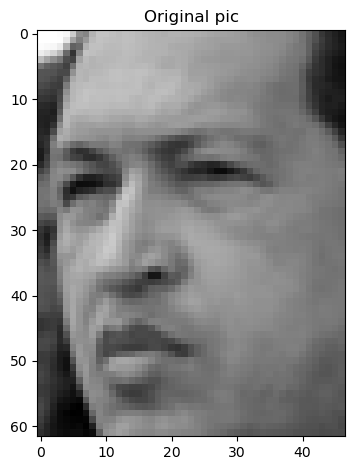

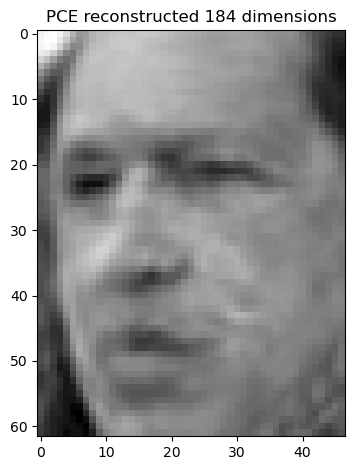

In [76]:
# Plot the images here

plt.figure()
plt.imshow(X[0, :].reshape((h, w)), cmap=plt.cm.gray) # original pic
plt.title(f'Original pic') # adding title to the pictures
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(Xhat[0, :].reshape((h, w)), cmap=plt.cm.gray) # plotting PCA dec/encoded pic
plt.title(f'PCE reconstructed {m} dimensions') # adding title to the pictures
plt.tight_layout()
plt.show()

**Comment:** Enter your comment here.

The reconstructed pic is not better in terms of visual quality, the point is to use the lower number of dimensions to keep the necessary information intact, rather than increasing the quality. Also, when desired POV (p) is adjusted, the picture gets better/worse.

# K-Means Clustering (Bachelor and master students)
In this section you will use the *k-means clustering* algorithm to perform unsupervised clustering. Then you will perform a qualitative assesment of the results.

### Importing scikit-learn library
We start importing the module `sklearn.cluster.KMeans` from the standard machine learning library `scikit-learn`.

In [35]:
from sklearn.cluster import KMeans

### Loading the data
We will use once again the *iris* data set. The function *get_iris_data()* from the module *syntethicdata* returns the *iris* dataset. It returns a data matrix of dimension [150x4] and a label vector of dimension [150].

In [36]:
X, y = syntheticdata.get_iris_data()

### Projecting the data using PCA
To allow for visualization, we project our data in two dimensions as we did previously. This step is not necessary, and we may want to try to use *k-means* later without the PCA pre-processing. However, we use PCA, as this will allow for an easy visualization.

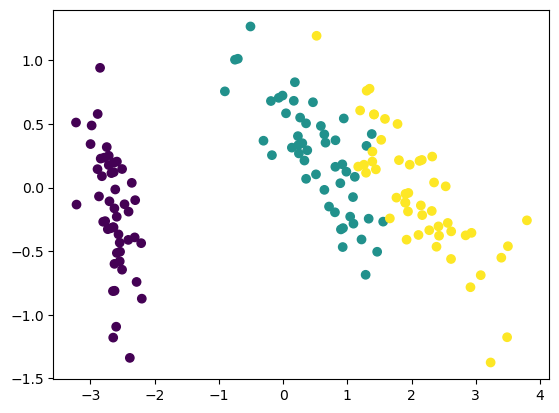

In [37]:
_, P5 = pca(X,2) 

plt.figure()
plt.scatter(P5[:,0], P5[:,1], c=y) # plotting 2d projection of the iris data set


### Running k-means
We will now consider the *iris* data set as an unlabeled set, and perform clustering to this unlabeled set. We can compare the results of the clustering to the lableled calsses.

Use the class *KMeans* to fit and predict the output of the *k-means* algorithm on the projected data. Run the algorithm using the following values of $k=\{2,3,4,5\}$. 

In [38]:
k_values = [2, 3, 4, 5] # 2,3,4,5 number of clusters
y_hats = [] # the store the predicted cluster lables for each k_value

for k in range(len(k_values)):
    KM = KMeans(n_clusters=k_values[k], random_state=0, n_init="auto")  # Fill inn correct value for k
    yhat = KM.fit_predict(P5)  # Store the prediction
    y_hats.append(yhat)

C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

### Qualitative assessment
Plot the results of running the k-means algorithm, compare with the true labels, and comment. Try to use `plt.subplot(n_rows, n_cols, position)` with titles to make a nice plot.

**Hint**: Plot the first and second dimension of `P` using `plt.scatter()`, and set the keyword argument `c` to the predictions made with KMeans.

C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

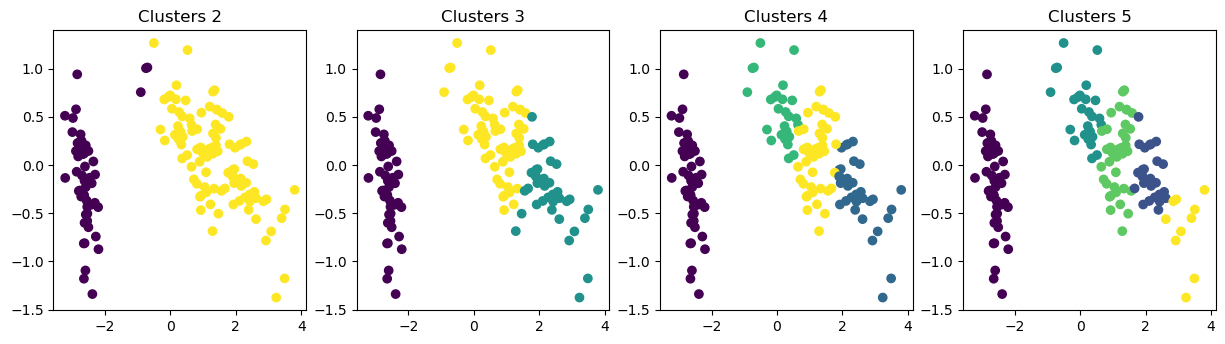

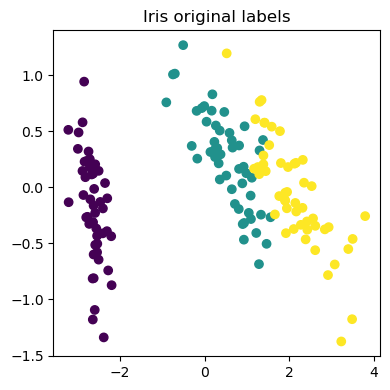

In [39]:

n_rows,n_cols = 2,4

k_values = [2, 3, 4, 5] # 2,3,4,5 number of clusters

plt.figure(figsize=(15,8))

for k in range(len(k_values)):
    
    KM = KMeans(n_clusters=k_values[k], random_state=0, n_init="auto") # calling K-means, create "new" targets
    #n_init = auto = sklearn determines num of initalizations based on the size of the dataset, '
    # to make sure that the clustering is robust/converges to a good solution
    yhat = KM.fit_predict(P5)   # predict on 2d PCA projection P5
    
    plt.subplot(n_rows,n_cols,k+1) # making cols*rows subplots
    plt.scatter(P5[:,0],P5[:,1],c=yhat) # scatter 2d, dots P5 based on yhat
    plt.title(f'Clusters {k+2}') # adding title to the pictures
    
    
plt.figure(figsize = (4,4))
plt.scatter(P5[:,0],P5[:,1],c=y)
plt.title(f'Iris original labels') # adding title to the pictures

plt.tight_layout()
plt.show()

**Comment:** Enter your comment here.

K-means is unsupervised, it doesn't use any true labels, but it groups the data together based on some underlying patterns in the dataset. However, without having a dataset y with true lables, there is no way of knowing what iteration of k_values actually pinpoints the most important features in our dataset. n_clusters could be based on the proximity of the datapoints but also on some other qualitative values in the datset, to mention a few.

Here we also plot the originals labels, and plot reveals that k_values = 3 hits closest to home.  

# Quantitative Assessment of K-Means (Bachelor and master students)

We used k-means for clustering and we assessed the results qualitatively by visualizing them. However, we often want to be able to measure in a quantitative way how good the clustering was. To do this, we will use a classification task to evaluate numerically the goodness of the representation learned via k-means.

Reload the *iris* dataset. Import a standard `LogisticRegression` classifier from the module `sklearn.linear_model`. Use the k-means representations learned previously (`yhat2,...,yhat5`) and the true label to train the classifier. Evaluate your model on the training data (we do not have a test set, so this procedure will assess the model fit instead of generalization) using the `accuracy_score()` function from the *sklearn.metrics* module. Plot a graph showing how the accuracy score varies when changing the value of k. Comment on the results.

- Train a Logistic regression model using the first two dimensions of the PCA of the iris data set as input, and the true classes as targets.
- Report the model fit/accuracy on the training set.
- For each value of K:
  - One-Hot-Encode the classes output by the K-means algorithm.
  - Train a Logistic regression model on the K-means classes as input vs the real classes as targets.
  - Calculate model fit/accuracy vs. value of K.
- Plot your results in a graph and comment on the K-means fit.

C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

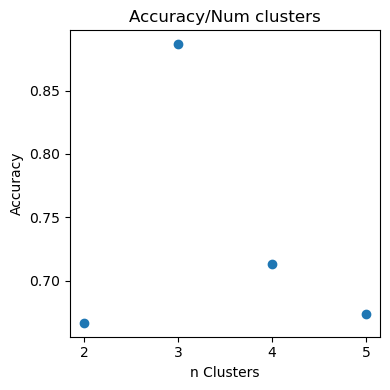

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score

X, y = syntheticdata.get_iris_data()
n_rows,n_cols = 2,4
k_values = [2, 3, 4, 5] # 2,3,4,5 number of clusters

accuracy = [] # to store accuracies
model = LogisticRegression() # instantiating a log reg model

for k in range(len(k_values)):
    
    KM = KMeans(n_clusters=k_values[k], random_state=0, n_init="auto") # calling K-means, create "new" targets,
    # n_init = auto = sklearn determines num of initalizations based on the size of the dataset, to make sure that the clustering is robust
    yhat = KM.fit_predict(P5)  # predict on 2d PCA projection P5
    yhat = yhat.reshape(-1,1) # reshaping to 2d matrix to use with logreg-sklearn
    model.fit(yhat,y) # train the model with k-means predictions and true labels
    y_pred = model.predict(yhat) # predict on the trained model based on k-means labels 
    accuracy.append(accuracy_score(y,y_pred)) # calc accuracy on y_pred held up againt y
    
plt.figure(figsize=(4,4))
plt.plot(k_values,accuracy,marker = 'o',linestyle = '')
plt.title(f'Accuracy/Num clusters')
plt.xlabel(f'n Clusters')
plt.ylabel(f'Accuracy')
plt.xticks(k_values) # restrict x-axis only to num of k_values  
plt.tight_layout()
plt.show()
plt.show()


**Comment:** It might not be a surprise that the highest accuracy is reached with 3 clusters, since there are 3 classes in the y dataset (0,1,2). K-means is unsupervised, it doesn't use any true labels, but it groups the data together based on their underlying features. By using logreg (supervised) in combination with K-means, we can determine with greater certainty the relevant features and assume, in this case, that 3 clusters reveal the dominant or most relevant attributes of the dataset   

C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda_installation\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

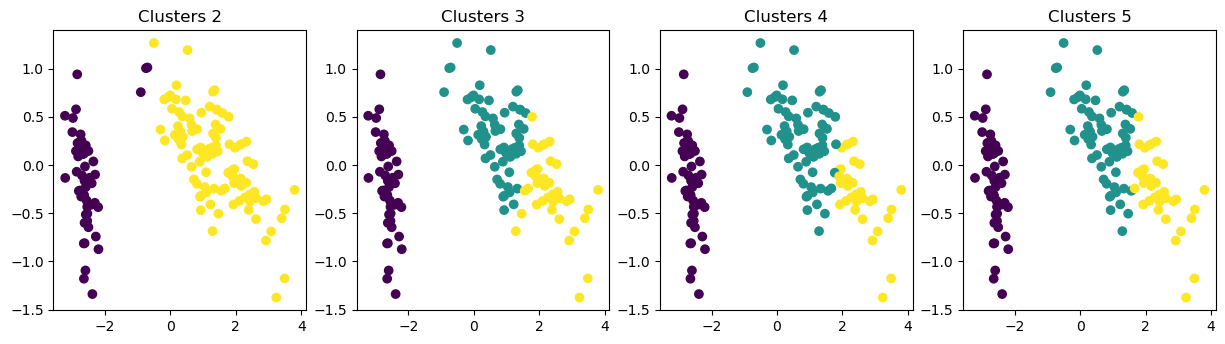

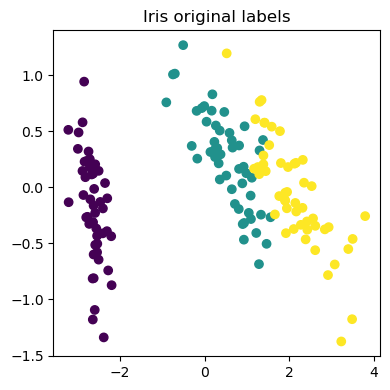

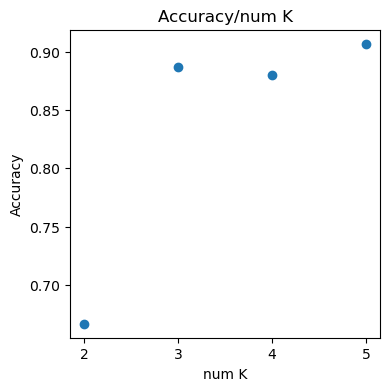

In [41]:
######################### ONE HOT ENCODING K-MEANS, LOG REG ########################################################

from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

X, y = syntheticdata.get_iris_data()
n_rows,n_cols = 2,4
k_values = [2, 3, 4, 5] # 2,3,4,5 number of clusters

accuracy = [] # to store accuracies
model = LogisticRegression() # instantiating a log reg model

plt.figure(figsize=(15,8))

for k in range(len(k_values)):
    KM = KMeans(n_clusters = k_values[k],random_state=0, n_init="auto")
    yhat = KM.fit_predict(P5)  # predict on 2d PCA projection P5
    yhat = yhat.reshape(-1,1) # reshaping to 2d matrix to use with logreg-sklearn
    
    OneHotEncode = OneHotEncoder(sparse_output=False) # initialze OneHotEncoder, sparse_output = false --> dense format on ouput
    yhat_encoded = OneHotEncode.fit_transform(yhat) # learning the categories, transforms into binary encoded  
    
    model.fit(yhat_encoded,y) # train the model with one hot encoded predictions and true labels
    yhat_pred_encoded = model.predict(yhat_encoded) # predict on the trained model based on one hot encoded labels 
    
    accuracy.append(accuracy_score(y,yhat_pred_encoded)) # calc accuracy on yhat_pred_encoded held up againt y
    
    plt.subplot(n_rows,n_cols,k+1) # making cols*rows subplots
    plt.scatter(P5[:,0],P5[:,1],c=yhat_pred_encoded) # scatter 2d, dots P5 based on yhat_pred_encoded
    plt.title(f'Clusters {k+2}') # adding title to the pictures
    
plt.figure(figsize = (4,4))
plt.scatter(P5[:,0],P5[:,1],c=y)
plt.title(f'Iris original labels') # adding title to the pictures

plt.tight_layout()
plt.show()

plt.figure(figsize=(4,4))
plt.plot(k_values,accuracy,marker = 'o',linestyle = '')
plt.title(f'Accuracy/num K')
plt.xlabel(f'num K')
plt.ylabel(f'Accuracy')
plt.xticks(k_values) # restrict x-axis only to num of k_values  
plt.show()



Comment: We now observe that despite making clusters with k_values = 2,3,4,5 the plot shows us only 3 classes with k = 3,4,5. This points to not actually finding meaningful seperations in the data beyond 3 clusters. The accuracy is a bit higher on k = 5. Compared to the original iris label - plot there is no big difference to observe, the same is the case for k = 3,4 in comparsion.
The result showing 3 classes with high accuracy emphasize the underlaying structure of the data. 
Since we have one hot encoded the K-means predictions and trained a log reg classifier, the problems that might arrive from representing higher dimensional data in lower space (PCA 2d), can be handled (if the PCA 2d and K-means leads to a classification problem) 

In [ ]:
# Conclusions 

In this notebook we studied **unsupervised learning** considering two important and representative algorithms: **PCA** and **k-means**.

First, we implemented the PCA algorithm step by step; we then run the algorithm on synthetic data in order to see its working and evaluate when it may make sense to use it and when not. We then considered two typical uses of PCA: for **visualization** on the *iris* dataset, and for **compression-decompression** on the *lfw* dateset.

We then moved to consider the k-means algorithm. In this case we used the implementation provided by *scikit-learn* and we applied it to another prototypical unsupervised learning problem: **clustering**; we used *k-means* to process the *iris* dataset and we evaluated the results visually.

In the final part, we considered two additional questions that may arise when using the above algorithms. For PCA, we considered the problem of **selection of hyper-parameters**, that is, how we can select the hyper-parameter of ou algorithm in a reasonable fashion. For k-means, we considered the problem of the **quantitative evaluation** of our results, that is, how can we measure the performance or usefulness of our algorithms. 